# 0. Setup

In [1]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kumo11 (kumo11_personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [2]:
import os, subprocess, sys

REPO_URL = "https://github.com/11erlangga/legal-rag-slm.git"
REPO_DIR = "/kaggle/working/repo"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

sys.path.append(REPO_DIR)

Cloning into '/kaggle/working/repo'...


In [3]:
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --upgrade "torchao>=0.16.0"
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1
  Attempting uninstall: datasets
    Found existing installation: datasets 5.0.0
    Uninstalling datasets-5.0.0:
      Successfully uninstalled datasets-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 63.3 MB/

In [4]:
!pip install -q rouge-score langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
from unsloth import FastLanguageModel

from src.data_utils import load_split_dataset
from src.reward_functions import extract_final_answer

pd.set_option("display.max_colwidth", 200)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# 1. Loss Curve Comparison: run1 (r=16) vs run2 (r=8)

## 1.1 Pull history dari W&B API

In [6]:
WANDB_ENTITY = "kumo11_personal"
WANDB_PROJECT = "legal-rag-slm-finetuning"
RUN1_ID = "gzy9oml7" # (r=16, alpha=16)
RUN2_ID = "4ucujf0v" # (r=8, alpha=8)

api = wandb.Api()
run1 = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{RUN1_ID}")
run2 = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{RUN2_ID}")

# Cek nama-nama kolom
cols_run1 = run1.history().columns.tolist()
print("Kolom tersedia di run1:")
print([c for c in cols_run1 if "loss" in c.lower()])

Kolom tersedia di run1:
['eval/loss', 'train/loss']


In [7]:
LOSS_TRAIN_KEY = "train/loss"
LOSS_EVAL_KEY = "eval/loss"  

hist1_train = run1.history(keys=[LOSS_TRAIN_KEY])
hist1_eval  = run1.history(keys=[LOSS_EVAL_KEY])
hist2_train = run2.history(keys=[LOSS_TRAIN_KEY])
hist2_eval  = run2.history(keys=[LOSS_EVAL_KEY])

print(f"run1 train points: {len(hist1_train)}, eval points: {len(hist1_eval)}")
print(f"run2 train points: {len(hist2_train)}, eval points: {len(hist2_eval)}")

run1 train points: 500, eval points: 10
run2 train points: 500, eval points: 10


## 1.2 Plot train_loss & eval_loss overlay

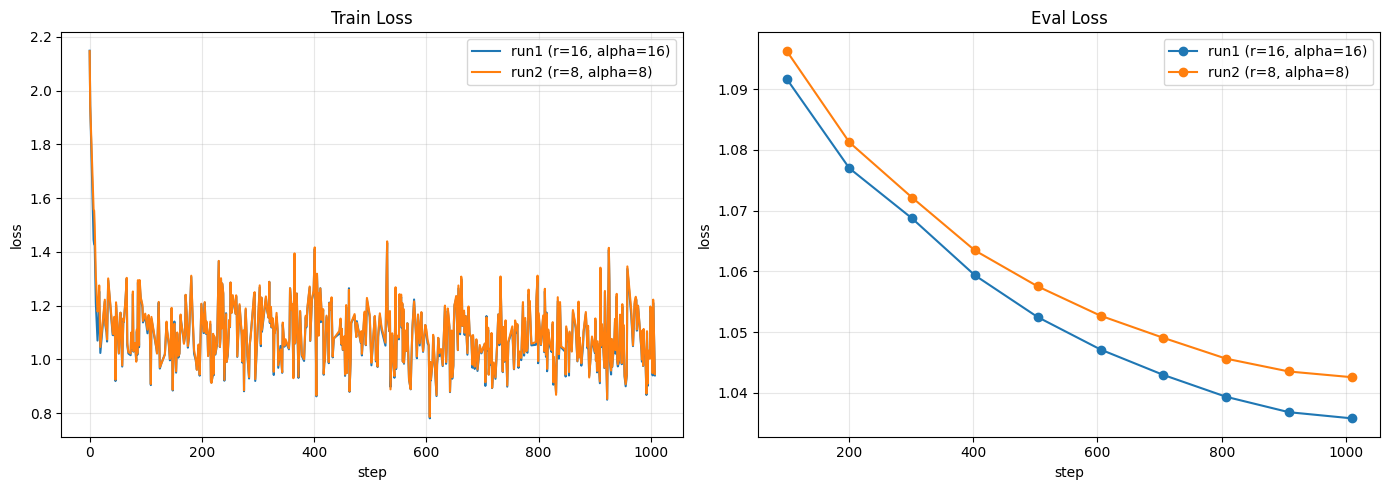

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist1_train["_step"], hist1_train[LOSS_TRAIN_KEY], label="run1 (r=16, alpha=16)")
axes[0].plot(hist2_train["_step"], hist2_train[LOSS_TRAIN_KEY], label="run2 (r=8, alpha=8)")
axes[0].set_title("Train Loss")
axes[0].set_xlabel("step")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist1_eval["_step"], hist1_eval[LOSS_EVAL_KEY], marker="o", label="run1 (r=16, alpha=16)")
axes[1].plot(hist2_eval["_step"], hist2_eval[LOSS_EVAL_KEY], marker="o", label="run2 (r=8, alpha=8)")
axes[1].set_title("Eval Loss")
axes[1].set_xlabel("step")
axes[1].set_ylabel("loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.3 Angka pendukung analisis

In [9]:
def summarize_run(hist_train, hist_eval, name):
    final_train = hist_train[LOSS_TRAIN_KEY].dropna().iloc[-1]
    final_eval = hist_eval[LOSS_EVAL_KEY].dropna().iloc[-1]
    min_eval = hist_eval[LOSS_EVAL_KEY].dropna().min()
    gap = final_train - final_eval
    return {
        "run": name,
        "final_train_loss": round(float(final_train), 4),
        "final_eval_loss": round(float(final_eval), 4),
        "min_eval_loss": round(float(min_eval), 4),
        "final_train_minus_eval_gap": round(float(gap), 4),
    }

summary_df = pd.DataFrame([
    summarize_run(hist1_train, hist1_eval, "run1 (r=16, alpha=16)"),
    summarize_run(hist2_train, hist2_eval, "run2 (r=8, alpha=8)"),
])
summary_df

,run,final_train_loss,final_eval_loss,min_eval_loss,final_train_minus_eval_gap
0,"run1 (r=16, alpha=16)",0.9405,1.0358,1.0358,-0.0953
1,"run2 (r=8, alpha=8)",0.9455,1.0426,1.0426,-0.0971


## 1.4 Keputusan

Tidak ada indikasi overfitting. Kedua kurva `eval_loss` masih menurun monoton sampai step 1000, gak ada titik belok ke atas. Di titik 1000 steps ini, belum ada bukti empiris salah satu run overfit lebih parah.

run1 selalu di bawah run2 — di semua 10 checkpoint (step 100 sampai 1000), bukan cuma di angka akhir. Ini pola yang jauh lebih meyakinkan dibanding kalau cuma "angka final run1 kebetulan lebih rendah" — karena konsisten dari awal sampai akhir, kemungkinan besar ini sinyal riil dari kapasitas model (r=16 > r=8), bukan noise kebetulan di satu titik.

Gap kedua hasil eksperimen negatif (eval > train) dan besarnya nyaris sama (selisih cuma 0.0018). Kalau r=16 benar-benar overfit lebih parah karena kapasitas lebih besar, harusnya gap-nya melebar jauh lebih besar dibanding run2. Faktanya gap-nya setara → run1 tidak membayar mahal untuk `eval_loss` yang lebih rendah itu, gak ada trade-off overfitting yang kelihatan di sini.

run1 (r=16, alpha=16) menang — lower `eval_loss` konsisten di semua checkpoint, generalization gap setara dengan run2 (gak ada indikasi overfitting ekstra), dan kedua kurva belum plateau.

Selisih `eval_loss` final cuma ~0.007 (1.0358 vs 1.0426) — kecil secara absolut, dan ini cuma 1 run per konfigurasi (gak ada repeated seed buat ukur variance run-to-run). Tapi karena konsisten di semua checkpoint bukan cuma di ujung, itu cukup buat jadi basis keputusan — gak perlu overclaim seolah ini beda yang dramatis.

**Isi manual di sini setelah baca grafik + tabel di atas:**

- Final eval_loss: run1 = `...` vs run2 = `...` -> mana yang lebih rendah?
- Gap train-vs-eval: run mana yang gap-nya lebih besar (indikasi overfitting lebih kuat)?
- Tren kurva eval_loss: apakah salah satu sempat naik lagi (overfitting) sebelum step 1000, atau masih menurun/plateau flat?
- **Kesimpulan (tulis 2-3 kalimat alasan, bukan cuma nama run):**

  `TODO: tulis alasan kamu di sini`

In [10]:
WINNER_HF_REPO_ID = "11erlangga/sft-qwen25-3b-run1"
WINNER_LABEL = "run 1"

print(f"Model terpilih: {WINNER_LABEL} -> {WINNER_HF_REPO_ID}")

Model terpilih: run 1 -> 11erlangga/sft-qwen25-3b-run1


# 2. Tuning `ROUGE_SIMILARITY_THRESHOLD`

## 2.1 Rebuild eval split

In [11]:
SPLIT_SEED = 1010
SPLIT_TEST_SIZE = 0.05

_, eval_ds = load_split_dataset(test_size=SPLIT_TEST_SIZE, seed=SPLIT_SEED)

print(f"Eval set size: {len(eval_ds)}")
print(eval_ds[0])

README.md: 0.00B [00:00, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Eval set size: 2499
{'input': 'Buatlah kalimat contoh menggunakan kata keterangan dan kata kerja yang diberikan.\ndengan hati-hati, mengemudi', 'output': 'Dia dengan hati-hati mengemudi melalui jalan-jalan sibuk di kota, memastikan untuk mematuhi semua aturan lalu lintas dan memperhatikan pejalan kaki.'}


## 2.2 Load model pemenang (inference mode)

In [12]:
MAX_SEQ_LENGTH = 2048 # sama dengan yang dipakai saat SFT
SYSTEM_PROMPT = "Kamu adalah asisten AI yang menjawab pertanyaan pengguna dengan akurat dan jelas dalam Bahasa Indonesia."

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=WINNER_HF_REPO_ID,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
    token=HF_TOKEN,
)
FastLanguageModel.for_inference(model)

==((====))==  Unsloth 2026.9.4: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
total weights      : 3.150 GiB
no_split classes   : ['Qwen2DecoderLayer']
output head        : lm_head -> cuda:1
head headroom      : 0.359 GiB
activation reserve : 11.233 GiB requested
tied to head       : ['model.embed_tokens']
  cuda:0  budget  12.98 GiB  weights  1.685 GiB  free 11.294 GiB  reserve 11.233 GiB
  cuda:1  budget  13.00 GiB  weights  1.466 GiB  free 11.530 GiB  reserve 11.062 GiB   <- output head
note: Bnb4BitHfQuantizer.adjust_max_memory lowered the budget on cuda:0 14.421 -> 12.979 GiB, cuda:1 14.440 -> 12.996 GiB (memory th

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 2048, padding_idx=151654)
    (layers): ModuleList(
      (0-35): 36 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=2048, out_features=2048, bias=True)
          (k_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=2048, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=2048, out_features=2048, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((

## 2.3 Sample & generate completion

In [13]:
N_SAMPLES = 20
random.seed(1010)
sample_indices = random.sample(range(len(eval_ds)), min(N_SAMPLES, len(eval_ds)))

def generate_completion(instruction, max_new_tokens=512):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": instruction},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    output_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,  # deterministic -> kita mau ukur kemampuan dasar model, bukan variasi sampling
    )
    generated_ids = output_ids[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

records = []
for idx in sample_indices:
    example = eval_ds[idx]
    instruction = example["input"]  # 'input' = instruksi itu sendiri (bukan format Alpaca standar)
    ground_truth = example["output"]

    raw_completion = generate_completion(instruction)
    final_answer = extract_final_answer(raw_completion)

    records.append({
        "idx": idx,
        "instruction": instruction,
        "ground_truth": ground_truth,
        "raw_completion": raw_completion,
        "final_answer": final_answer,
    })

## 2.4 Hitung ROUGE-L fmeasure per sample

In [14]:
scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)  # stemmer False -> ini teks Indonesia, bukan English

for r in records:
    score = scorer.score(r["ground_truth"], r["final_answer"])
    r["rougeL_fmeasure"] = score["rougeL"].fmeasure

results_df = pd.DataFrame(records)
results_df[["idx", "rougeL_fmeasure"]]

,idx,rougeL_fmeasure
0,2473,0.235294
1,1011,0.230769
2,2188,0.064935
3,340,0.271605
4,1682,0.342756
5,1778,0.222222
6,1688,1.000000
7,673,0.160550
8,583,0.543210
9,1788,0.277372


## 2.5 Distribusi skor

count    20.000000
mean      0.260921
std       0.215430
min       0.000000
25%       0.162795
50%       0.218862
75%       0.273047
max       1.000000
Name: rougeL_fmeasure, dtype: float64


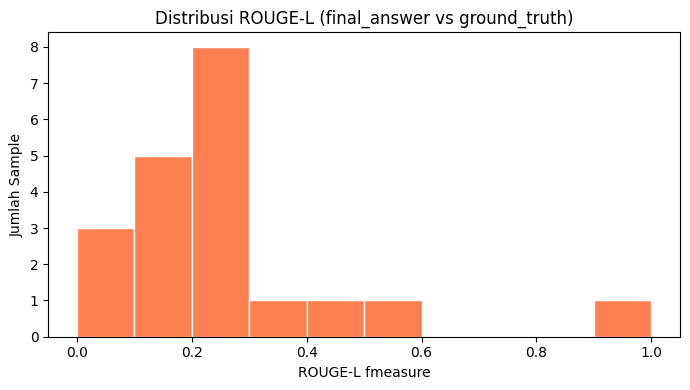

In [15]:
print(results_df["rougeL_fmeasure"].describe())

plt.figure(figsize=(7, 4))
plt.hist(results_df["rougeL_fmeasure"], bins=10, color="coral", edgecolor="white")
plt.xlabel("ROUGE-L fmeasure")
plt.ylabel("Jumlah Sample")
plt.title("Distribusi ROUGE-L (final_answer vs ground_truth)")
plt.tight_layout()
plt.show()

## 2.6 Qualitative check

**Jangan skip bagian ini** - lihat langsung isi teksnya, bukan cuma angka. Tujuannya: cari titik potong yang
secara *makna* memisahkan 'jawaban relevan' vs 'ngawur', bukan angka statistik (misal median) yang dipilih buta.

In [16]:
# Urutkan dari skor terendah ke tertinggi -> lihat beberapa contoh di tiap band
sorted_df = results_df.sort_values("rougeL_fmeasure")

def show_band(df, low, high, n=3):
    band = df[(df["rougeL_fmeasure"] >= low) & (df["rougeL_fmeasure"] < high)]
    print(f"Band [{low}, {high}) | {len(band)} sample")
    for _, row in band.head(n).iterrows():
        print(f"[score={row['rougeL_fmeasure']:.3f}] instruksi: {row['instruction']}")
        print(f"  ground_truth : {row['ground_truth']}")
        print(f"  final_answer : {row['final_answer']}")

show_band(sorted_df, 0.0, 0.3, n=16)
show_band(sorted_df, 0.3, 0.6)
show_band(sorted_df, 0.6, 1.01)

Band [0.0, 0.3) | 16 sample
[score=0.000] instruksi: Susun kata-kata berikut dalam urutan sesuai abjad.

  ground_truth : Alice, Di, Hidup, Kota
  final_answer : A, B, C, D, E, F, G, H, I, J, K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z
[score=0.037] instruksi: Buatlah tanda tangan email yang dipersonalisasi.
Tidak ada konteks yang jelas atau relevan dengan permintaan terjemahan yang diberikan. Mohon berikan konteks yang lebih rinci dan relevan untuk membantu dalam memberikan terjemahan yang akurat.
  ground_truth : Salam terbaik,  
John Doe

---
John Doe | Email: john.doe@email.com | Phone: (XXX) XXX-XXXX
Linkedin: www.linkedin.com/in/johndoe | Twitter: @john_doe
"Bersungguh-sungguhlah untuk menjadi berharga, bukan sekadar sukses" - Albert Einstein
  final_answer : Untuk mempersonalisasi tanda tangan email, Anda dapat menambahkan informasi pribadi seperti nama lengkap, posisi, dan alamat email Anda. Berikut contoh tanda tangan email yang dipersonalisasi:

Halo [Nama Pengirim],

Saya

## 2.7 Keputusan

**Manual review cluster ROUGE 0.15–0.28 (13 sample) + gabungan dengan 7 sample sebelumnya**

Kategorisasi tiap sample (kategori 1: data rusak/unanswerable, 2: open-ended/instruksi ambigu, 3: paraphrase benar, 4: model salah):

| idx | skor | kategori | catatan singkat |
|---|---|---|---|
| 1788 | 0.159 | 2 | cerita robot beda, sama valid |
| 673 | 0.161 | **4** | repetition collapse (kalimat sama diulang >10x) |
| 836 | 0.164 | 2 | desain website beda struktur, sama valid |
| 2088 | 0.186 | **3** | CNN — konsep sama, istilah beda, terpotong token limit |
| 1605 | 0.196 | 2 | perumpamaan — jawaban model valid, GT-nya yang aneh (translate puisi) |
| 2070 | 0.212 | 2 | artikel lingkungan — tema sama, detail beda |
| 2473 | 0.216 | 2 | onboarding — struktur beda, sama valid |
| 1778 | 0.222 | **3** | iPhone XS Max — fakta utama benar, minor error (kamera depan) |
| 1011 | 0.231 | **4** | contoh produk — pelanggaran constraint eksplisit ($10.25 di luar range $9-10) |
| 1458 | 0.231 | 2b | instruksi ambigu itu sendiri ("identifikasi jenis" tidak jelas maksudnya) |
| 340 | 0.235 | 2 | layanan akuntan — poin agak redundan tapi valid |
| 1682 (Romeo&Juliet) | 0.272 | **4** | kesalahan faktual isi cerita (siapa yang dipaksa nikah) |
| 1958 (argumen laut) | 0.277 | 2 | kritik argumen yang defensible |

**Temuan kunci:** kategori 3 (skor terendah 0.186) dan kategori 4 (skor tertinggi 0.277) **tumpang tindih rentang skornya**. ROUGE-L gak bisa jadi pembeda bersih di rentang 0.15–0.28.

**Keputusan: `ROUGE_SIMILARITY_THRESHOLD_FINAL = 0.2`**
- Dipilih sedikit di bawah 0.186 (skor kategori 3 terendah) supaya paraphrase valid gak ke-nol-kan.
- Konsekuensi: 1 sample kategori 4 (repetition collapse, skor 0.161) tetap lolos dapat reward positif — diterima sebagai noise (~5% dari 20 sample), didokumentasikan sebagai known limitation, bukan ditutupi.
- Alasan gak dinaikkan lebih tinggi: correctness reward adalah satu-satunya sinyal isi-jawaban dari 4 reward function GRPO — kalau threshold terlalu konservatif, sample benar (kategori 3) ikut ke-nol-kan dan sinyal ini jadi gak informatif.

In [17]:
ROUGE_SIMILARITY_THRESHOLD_FINAL = 0.2
print(f"Threshold final: {ROUGE_SIMILARITY_THRESHOLD_FINAL}")

Threshold final: 0.2
